# RDU Hourly Temperature: Data Cleanliness

Initial EDA for an hourly temperature prediction model at Raleigh-Durham International Airport (RDU). This notebook focuses on data quality and split consistency before feature selection or modeling.

The checks cover training and validation only: schema and types, missing values, duplicate records and timestamps, hourly timeline continuity, target availability, and implausible observed RDU temperatures. The inference dataset is intentionally excluded from EDA. Missing values are reported, not imputed. Temperature-range flags are a broad screening heuristic, not automatic corrections.

Run from the repository root or this `EDA/` directory.

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd()
ROOT = cwd.parent if (cwd / "Data").is_dir() is False and (cwd.parent / "Data").is_dir() else cwd
DATA_DIR = ROOT / "Data"
FILES = {
    "train": DATA_DIR / "train_dataset_2024_aug2026.csv",
    "validation": DATA_DIR / "val_dataset_sept01_sept16_2026.csv",
}

missing_files = [str(path) for path in FILES.values() if not path.is_file()]
if missing_files:
    raise FileNotFoundError(f"Could not find expected data files: {missing_files}")

frames = {name: pd.read_csv(path) for name, path in FILES.items()}
print(f"Project root: {ROOT}")
print("Loaded row counts:", {name: len(frame) for name, frame in frames.items()})

Project root: /Users/govils/Desktop/Duke/AIPI 520/Project 1
Loaded row counts: {'train': 23376, 'validation': 384}


## Dataset overview

Review row/column counts, inferred dtypes, and sample records. The data use `valid_edt` as the row's hourly timestamp; `rdu_tmpf` is the observed RDU temperature column when available.

In [9]:
for name, frame in frames.items():
    print(f"\n{'=' * 18} {name.upper()} {'=' * 18}")
    print(f"Shape: {frame.shape[0]:,} rows x {frame.shape[1]:,} columns")
    display(pd.DataFrame({"dtype": frame.dtypes.astype(str), "non_null": frame.notna().sum(), "null": frame.isna().sum()}))
    display(frame.head(3))


================== TRAIN ==================
Shape: 23,376 rows x 85 columns


,dtype,non_null,null
valid_edt,str,23376,0
fay_alti,float64,23280,96
gso_alti,float64,23376,0
rdu_alti,float64,23375,1
rwi_alti,float64,23187,189
...,...,...,...
grad_gso_minus_rdu_tmpf,float64,23373,3
grad_rwi_minus_rdu_tmpf,float64,23153,223
gfs_dewpoint_depression,float64,23376,0
gfs_estimated_ghi,float64,0,23376


,valid_edt,fay_alti,gso_alti,rdu_alti,rwi_alti,fay_drct,gso_drct,rdu_drct,rwi_drct,fay_dwpf,...,rwi_tmpf_lag_6h,rwi_tmpf_lag_12h,rwi_tmpf_lag_24h,rwi_tmpf_lag_48h,grad_fay_minus_rdu_tmpf,grad_gso_minus_rdu_tmpf,grad_rwi_minus_rdu_tmpf,gfs_dewpoint_depression,gfs_estimated_ghi,gfs_temp_residual
0,2024-01-01 00:00:00,30.057692,30.0,30.033846,30.047692,211.538462,213.076923,233.846154,160.769231,34.0,...,NaN,NaN,NaN,NaN,-3.0,-6.0,-5.0,5.296667,NaN,0.546667
1,2024-01-01 01:00:00,30.050000,30.0,30.020000,30.038333,228.461538,221.538462,233.846154,182.500000,35.0,...,NaN,NaN,NaN,NaN,-1.0,-6.0,-4.0,5.760000,NaN,-0.530000
2,2024-01-01 02:00:00,30.050000,30.0,30.021667,30.031538,220.833333,213.846154,236.666667,179.230769,35.0,...,NaN,NaN,NaN,NaN,0.0,-6.0,-3.0,5.493333,NaN,-1.070000



================== VALIDATION ==================
Shape: 384 rows x 85 columns


,dtype,non_null,null
valid_edt,str,384,0
fay_alti,float64,384,0
gso_alti,float64,384,0
rdu_alti,float64,384,0
rwi_alti,float64,384,0
...,...,...,...
grad_gso_minus_rdu_tmpf,float64,384,0
grad_rwi_minus_rdu_tmpf,float64,384,0
gfs_dewpoint_depression,float64,384,0
gfs_estimated_ghi,float64,0,384


,valid_edt,fay_alti,gso_alti,rdu_alti,rwi_alti,fay_drct,gso_drct,rdu_drct,rwi_drct,fay_dwpf,...,rwi_tmpf_lag_6h,rwi_tmpf_lag_12h,rwi_tmpf_lag_24h,rwi_tmpf_lag_48h,grad_fay_minus_rdu_tmpf,grad_gso_minus_rdu_tmpf,grad_rwi_minus_rdu_tmpf,gfs_dewpoint_depression,gfs_estimated_ghi,gfs_temp_residual
0,2026-09-01 00:00:00,30.092308,30.11,30.094615,30.090000,197.692308,218.461538,70.769231,183.076923,74.0,...,89.0,91.0,72.000,69.40,-2.0,-4.0,-1.0,12.776667,NaN,0.70
1,2026-09-01 01:00:00,30.092308,30.11,30.100000,30.096154,203.846154,171.538462,114.615385,196.923077,74.0,...,83.0,93.0,69.400,69.00,-3.0,-5.0,-2.0,12.103333,NaN,1.69
2,2026-09-01 02:00:00,30.081538,30.11,30.093077,30.085385,217.692308,146.153846,165.384615,202.307692,74.0,...,79.0,94.0,68.125,70.92,-3.0,-4.0,-3.0,11.430000,NaN,2.68


## Missingness

These summaries show where values are absent within the training and validation datasets. Missingness is reported rather than imputed at this stage.

,train,validation,max_missing_pct
gfs_cloud_cover_pct,100.00,100.00,100.00
gfs_estimated_ghi,100.00,100.00,100.00
gfs_sknt,100.00,100.00,100.00
valid,66.67,66.93,66.93
forecast_hour,66.67,66.93,66.93
init_valid,66.67,66.93,66.93
rdu_mslp,1.24,0.00,1.24
rwi_tmpf_lag_48h,1.15,0.00,1.15
rwi_dwpf,1.09,0.00,1.09
rwi_relh,1.09,0.00,1.09



Train: columns with the most missing values (%)


,missing_pct
gfs_cloud_cover_pct,100.00
gfs_estimated_ghi,100.00
gfs_sknt,100.00
valid,66.67
forecast_hour,66.67
init_valid,66.67
rdu_mslp,1.24
rwi_tmpf_lag_48h,1.15
rwi_dwpf,1.09
rwi_relh,1.09


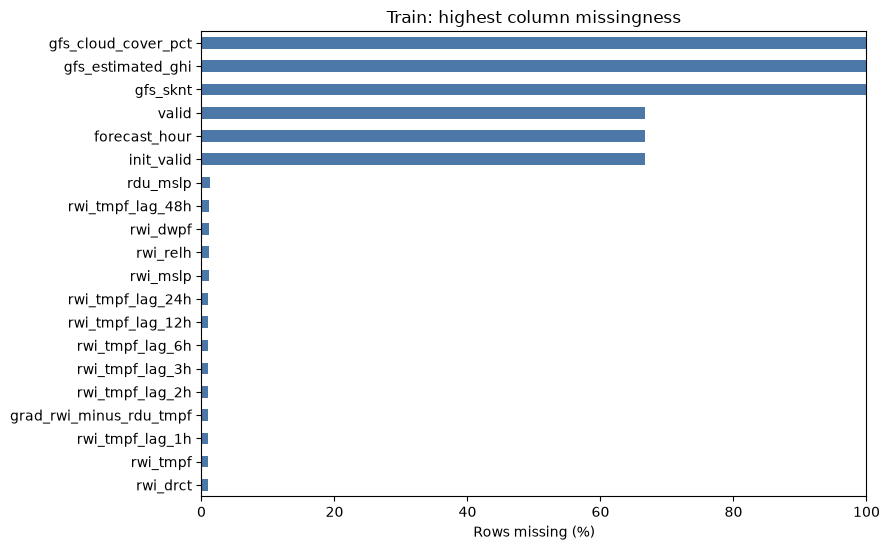


Validation: columns with the most missing values (%)


,missing_pct
gfs_estimated_ghi,100.00
gfs_sknt,100.00
gfs_cloud_cover_pct,100.00
init_valid,66.93
forecast_hour,66.93
valid,66.93
fay_mslp,1.04
fay_relh,0.26
fay_tmpf_lag_24h,0.26
fay_tmpf_lag_12h,0.26


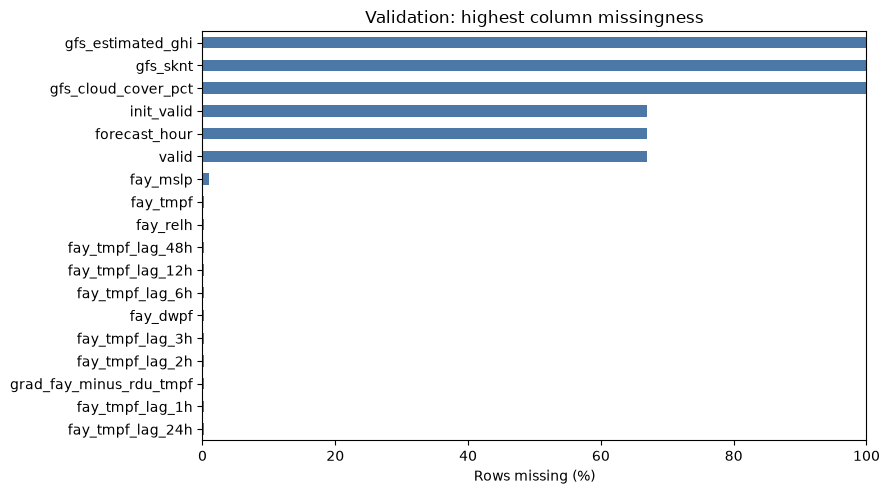

In [10]:
missingness = pd.concat(
    {
        name: (frame.isna().mean().mul(100).rename("missing_pct"))
        for name, frame in frames.items()
    },
    axis=1,
).fillna(0)
missingness["max_missing_pct"] = missingness.max(axis=1)
display(missingness.sort_values("max_missing_pct", ascending=False).head(30).round(2))

for name, frame in frames.items():
    rates = frame.isna().mean().mul(100).sort_values(ascending=False)
    rates = rates[rates.gt(0)].head(20)
    print(f"\n{name.title()}: columns with the most missing values (%)")
    display(rates.rename("missing_pct").to_frame().round(2))
    if not rates.empty:
        ax = rates.sort_values().plot.barh(figsize=(9, max(3, 0.28 * len(rates))), color="#4C78A8")
        ax.set(title=f"{name.title()}: highest column missingness", xlabel="Rows missing (%)", ylabel="")
        ax.set_xlim(0, 100)
        plt.tight_layout()
        plt.show()

## Duplicate records and timestamp quality

For each split, check exact duplicate rows and duplicate parsed `valid_edt` values. Then check timestamp parse failures, chronological ordering, and gaps longer than one hour between distinct timestamps. This does not assume timestamps are UTC; it parses the supplied wall-clock values as represented.

In [11]:
TIMESTAMP_COL = "valid_edt"

def timeline_checks(frame: pd.DataFrame) -> dict:
    if TIMESTAMP_COL not in frame.columns:
        return {"error": f"Missing {TIMESTAMP_COL!r} column"}

    parsed = pd.to_datetime(frame[TIMESTAMP_COL], errors="coerce")
    valid = parsed.dropna()
    unique_sorted = valid.drop_duplicates().sort_values()
    deltas = unique_sorted.diff().dropna()
    gaps = deltas[deltas > pd.Timedelta(hours=1)]
    return {
        "rows": len(frame),
        "timestamp_null_or_unparseable": int(parsed.isna().sum()),
        "timestamp_min": valid.min(),
        "timestamp_max": valid.max(),
        "input_order_is_chronological": bool(valid.is_monotonic_increasing),
        "duplicate_timestamp_rows": int(parsed.duplicated(keep=False).sum()),
        "extra_rows_at_duplicate_timestamps": int(parsed.duplicated(keep="first").sum()),
        "unique_timestamp_count": int(valid.nunique()),
        "gaps_over_one_hour": int(gaps.size),
        "missing_hour_bins_across_gaps": int(sum(max(int(delta / pd.Timedelta(hours=1)) - 1, 0) for delta in gaps)),
        "largest_gap": gaps.max() if not gaps.empty else pd.Timedelta(0),
    }

duplicate_summary = pd.DataFrame(
    {
        name: {
            "exact_duplicate_rows": int(frame.duplicated().sum()),
            "columns": frame.shape[1],
        }
        for name, frame in frames.items()
    }
).T
display(duplicate_summary)
timeline_summary = pd.DataFrame({name: timeline_checks(frame) for name, frame in frames.items()}).T
display(timeline_summary)

,exact_duplicate_rows,columns
train,0,85
validation,0,85


,rows,timestamp_null_or_unparseable,timestamp_min,timestamp_max,input_order_is_chronological,duplicate_timestamp_rows,extra_rows_at_duplicate_timestamps,unique_timestamp_count,gaps_over_one_hour,missing_hour_bins_across_gaps,largest_gap
train,23376,0,2024-01-01 00:00:00,2026-08-31 23:00:00,True,0,0,23376,0,0,0 days 00:00:00
validation,384,0,2026-09-01 00:00:00,2026-09-16 23:00:00,True,0,0,384,0,0,0 days 00:00:00


## Target availability and observed RDU temperature

Summarize `rdu_tmpf` separately from lagged temperature features. Temperatures outside -100°F to 140°F are flagged for inspection as broad plausibility outliers; the threshold does not modify or remove data.

,target_present,target_non_null,target_missing_pct,min_F,median_F,max_F,outside_-100_to_140_F,lag_feature_count
split,,,,,,,,
train,True,23374,0.01,12.0,66.000000,104.0,0,7
validation,True,384,0.00,61.0,78.666667,101.0,0,7



Train: observed rdu_tmpf quantiles (°F)


,temperature_F
count,23374.000000
mean,63.594754
std,17.164046
min,12.000000
1%,24.000000
25%,51.000000
50%,66.000000
75%,77.000000
99%,95.000000
max,104.000000


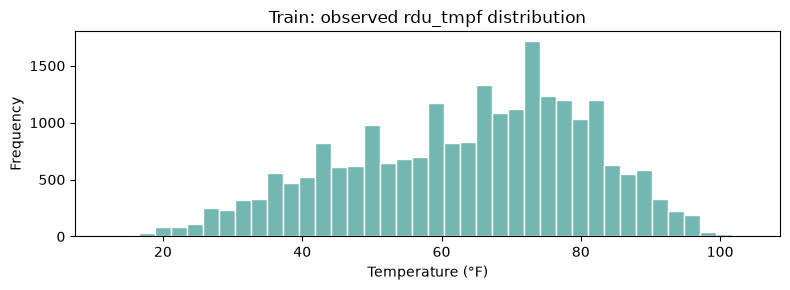


Validation: observed rdu_tmpf quantiles (°F)


,temperature_F
count,384.000000
mean,79.917882
std,8.426432
min,61.000000
1%,63.000000
25%,75.000000
50%,78.666667
75%,85.000000
99%,98.170000
max,101.000000


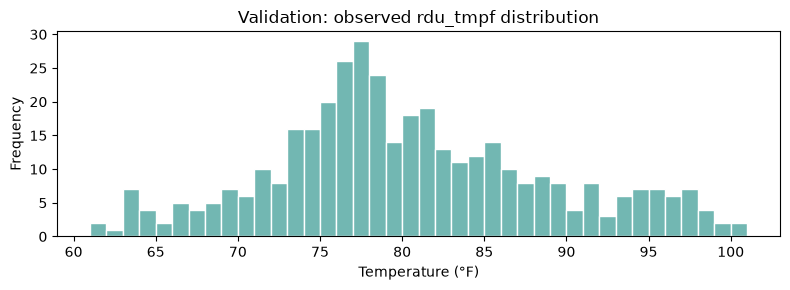

Lagged RDU temperature features:
  train: ['rdu_tmpf_lag_1h', 'rdu_tmpf_lag_2h', 'rdu_tmpf_lag_3h', 'rdu_tmpf_lag_6h', 'rdu_tmpf_lag_12h', 'rdu_tmpf_lag_24h', 'rdu_tmpf_lag_48h']
  validation: ['rdu_tmpf_lag_1h', 'rdu_tmpf_lag_2h', 'rdu_tmpf_lag_3h', 'rdu_tmpf_lag_6h', 'rdu_tmpf_lag_12h', 'rdu_tmpf_lag_24h', 'rdu_tmpf_lag_48h']


In [12]:
TARGET_COL = "rdu_tmpf"
lag_columns = {
    name: [column for column in frame.columns if column.startswith("rdu_tmpf_lag_")]
    for name, frame in frames.items()
}

target_rows = []
for name, frame in frames.items():
    if TARGET_COL not in frame.columns:
        target_rows.append({"split": name, "target_present": False, "target_non_null": 0, "target_missing_pct": np.nan})
        continue
    target = pd.to_numeric(frame[TARGET_COL], errors="coerce")
    observed = target.dropna()
    outliers = observed[(observed < -100) | (observed > 140)]
    target_rows.append({
        "split": name,
        "target_present": True,
        "target_non_null": int(observed.size),
        "target_missing_pct": round(float(target.isna().mean() * 100), 2),
        "min_F": observed.min() if not observed.empty else np.nan,
        "median_F": observed.median() if not observed.empty else np.nan,
        "max_F": observed.max() if not observed.empty else np.nan,
        "outside_-100_to_140_F": int(outliers.size),
        "lag_feature_count": len(lag_columns[name]),
    })
    if not outliers.empty:
        display(frame.loc[outliers.index, [column for column in [TIMESTAMP_COL, TARGET_COL] if column in frame.columns]])

display(pd.DataFrame(target_rows).set_index("split"))
for name, frame in frames.items():
    if TARGET_COL in frame.columns:
        values = pd.to_numeric(frame[TARGET_COL], errors="coerce").dropna()
        if not values.empty:
            print(f"\n{name.title()}: observed {TARGET_COL} quantiles (°F)")
            display(values.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).to_frame(name="temperature_F"))
            ax = values.plot.hist(bins=40, figsize=(8, 3), color="#72B7B2", edgecolor="white")
            ax.set(title=f"{name.title()}: observed {TARGET_COL} distribution", xlabel="Temperature (°F)")
            plt.tight_layout()
            plt.show()

print("Lagged RDU temperature features:")
for name, columns in lag_columns.items():
    print(f"  {name}: {columns}")

## Split schema comparison

Compare the validation columns against the training schema. The inference dataset is excluded from this analysis.

In [13]:
train_columns = set(frames["train"].columns)
schema_rows = []
for name, frame in frames.items():
    columns = set(frame.columns)
    schema_rows.append({
        "split": name,
        "column_count": len(columns),
        "columns_missing_vs_train": sorted(train_columns - columns),
        "columns_extra_vs_train": sorted(columns - train_columns),
        "rdu_tmpf_present": TARGET_COL in columns,
        "valid_edt_present": TIMESTAMP_COL in columns,
    })
display(pd.DataFrame(schema_rows).set_index("split"))

shared_columns = set.intersection(*(set(frame.columns) for frame in frames.values()))
dtype_mismatches = {
    column: {name: str(frame[column].dtype) for name, frame in frames.items()}
    for column in sorted(shared_columns)
    if len({str(frame[column].dtype) for frame in frames.values()}) > 1
}
print(f"\nShared columns with differing inferred dtypes: {len(dtype_mismatches)}")
for column, split_dtypes in dtype_mismatches.items():
    print(f"{column}: {split_dtypes}")

,column_count,columns_missing_vs_train,columns_extra_vs_train,rdu_tmpf_present,valid_edt_present
split,,,,,
train,85,[],[],True,True
validation,85,[],[],True,True



Shared columns with differing inferred dtypes: 0


## Initial notes

Use the outputs above to record actionable data-quality findings before modeling.

## Modeling signals: time series and candidate predictors

This section explores target autocorrelation, daily/seasonal patterns, and feature relationships for predicting temperature at each row's `valid_edt`. Candidate ranking uses **training only**; validation is reserved for simple lag-based baselines. The inference dataset remains excluded.

The training table has target temperature `rdu_tmpf` at each valid hour and lagged temperatures that can serve as historical predictors. Candidate screening focuses on lagged observations, GFS forecast fields, and deterministic calendar/solar features. Contemporaneous observed station fields and target-derived features (such as residuals or gradients using current RDU temperature) are excluded. Correlation is only a screening tool: confirm every feature is available at the intended forecast issue time, especially GFS forecast initialization/lead time and observation latency.

,autocorrelation
lag_hours,
1,0.990
2,0.971
3,0.943
6,0.839
12,0.707
24,0.894
48,0.825
72,0.803
168,0.762


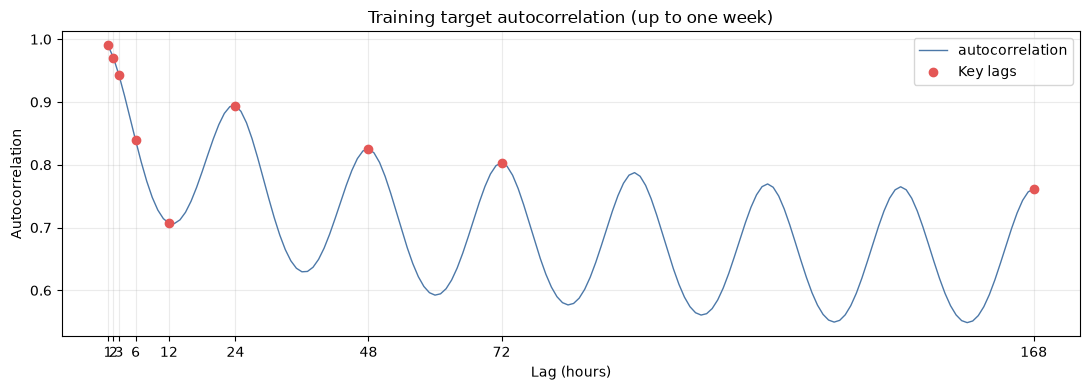

In [20]:
train_ts = frames["train"].copy()
train_ts[TIMESTAMP_COL] = pd.to_datetime(train_ts[TIMESTAMP_COL], errors="coerce")
train_ts[TARGET_COL] = pd.to_numeric(train_ts[TARGET_COL], errors="coerce")
train_ts = train_ts.sort_values(TIMESTAMP_COL).set_index(TIMESTAMP_COL)
target_series = train_ts[TARGET_COL]

max_lag_hours = 24 * 7
target_acf = pd.Series(
    {lag: target_series.autocorr(lag=lag) for lag in range(1, max_lag_hours + 1)},
    name="autocorrelation",
)
key_lags = [1, 2, 3, 6, 12, 24, 48, 72, 168]
display(target_acf.loc[key_lags].rename_axis("lag_hours").to_frame().round(3))

ax = target_acf.plot(figsize=(11, 4), color="#4C78A8", linewidth=1)
ax.scatter(key_lags, target_acf.loc[key_lags], color="#E45756", zorder=3, label="Key lags")
ax.set(title="Training target autocorrelation (up to one week)", xlabel="Lag (hours)", ylabel="Autocorrelation")
ax.set_xticks(key_lags)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

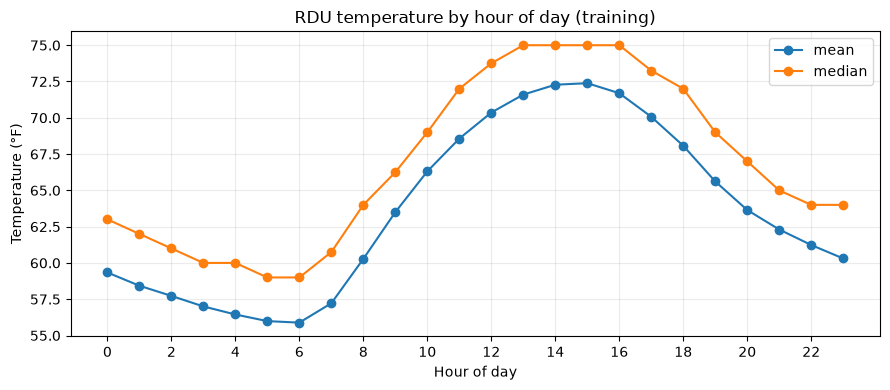

,mean,median
month,,
1,41.1,40.0
2,46.7,47.0
3,58.1,58.0
4,66.0,67.0
5,70.7,71.0
6,80.4,80.0
7,81.7,80.0
8,77.5,77.0
9,72.2,72.0


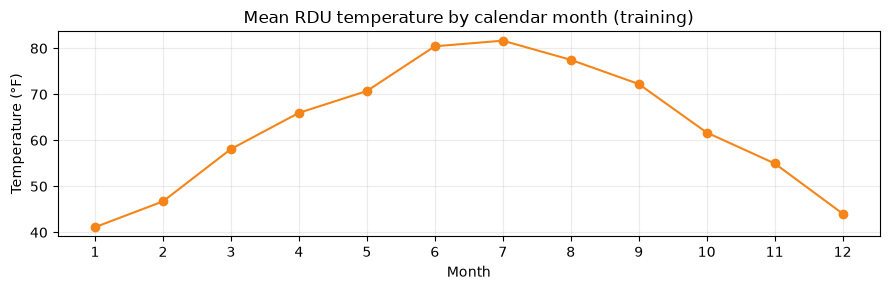

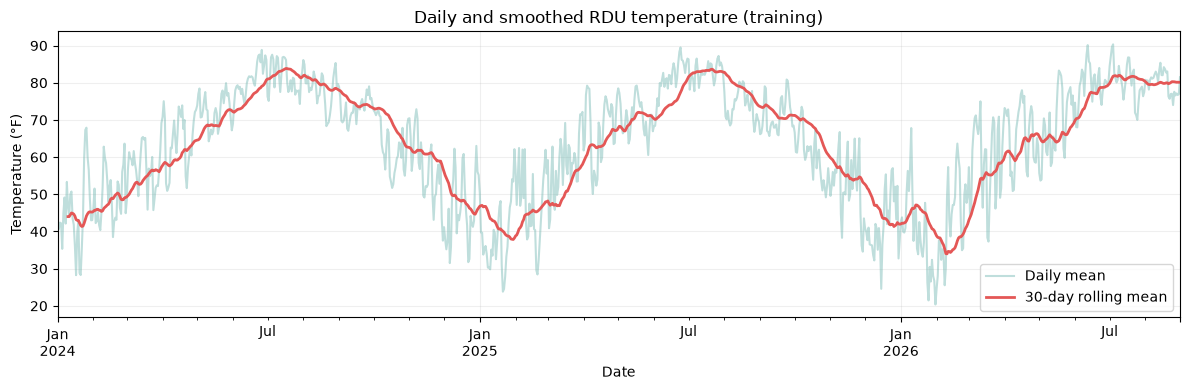

In [16]:
seasonal = train_ts[[TARGET_COL]].dropna().copy()
seasonal["hour"] = seasonal.index.hour
seasonal["month"] = seasonal.index.month

hour_profile = seasonal.groupby("hour")[TARGET_COL].agg(["mean", "median"])
ax = hour_profile.plot(figsize=(9, 4), marker="o")
ax.set(title="RDU temperature by hour of day (training)", xlabel="Hour of day", ylabel="Temperature (°F)", xticks=range(0, 24, 2))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

month_profile = seasonal.groupby("month")[TARGET_COL].agg(["mean", "median"])
display(month_profile.round(1))
ax = month_profile["mean"].plot(figsize=(9, 3), marker="o", color="#F58518")
ax.set(title="Mean RDU temperature by calendar month (training)", xlabel="Month", ylabel="Temperature (°F)", xticks=range(1, 13))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

daily_mean = train_ts[TARGET_COL].resample("D").mean()
ax = daily_mean.plot(figsize=(12, 4), alpha=0.45, label="Daily mean", color="#72B7B2")
daily_mean.rolling(30, min_periods=10).mean().plot(ax=ax, linewidth=2, label="30-day rolling mean", color="#E45756")
ax.set(title="Daily and smoothed RDU temperature (training)", xlabel="Date", ylabel="Temperature (°F)")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
calendar_solar_features = {
    "sin_hour", "cos_hour", "sin_day", "cos_day", "daylength_hours",
    "solar_zenith", "solar_elevation", "solar_azimuth", "is_daylight",
    "toa_irradiance", "clearsky_ghi",
}
candidate_features = []
all_null_candidate_features = []
for column in train_ts.columns:
    is_lag = "_lag_" in column
    is_gfs_forecast = column.startswith("gfs_") and column != "gfs_temp_residual"
    is_calendar_solar = column in calendar_solar_features
    is_target_derived = "rdu_tmpf" in column and not is_lag
    if (is_lag or is_gfs_forecast or is_calendar_solar) and not is_target_derived:
        if pd.api.types.is_numeric_dtype(train_ts[column]):
            if train_ts[column].notna().any():
                candidate_features.append(column)
            else:
                all_null_candidate_features.append(column)

correlation_rows = []
for column in candidate_features:
    paired = pd.concat([train_ts[column].rename("feature"), target_series.rename("target")], axis=1).dropna()
    if len(paired) < 2:
        continue
    correlation_rows.append({
        "feature": column,
        "n_paired": len(paired),
        "coverage_pct": 100 * len(paired) / target_series.notna().sum(),
        "pearson_r": paired["feature"].corr(paired["target"]),
        "spearman_r": paired["feature"].corr(paired["target"], method="spearman"),
    })

feature_screen = pd.DataFrame(correlation_rows)
if feature_screen.empty:
    print("No numeric candidate features were available for screening.")
else:
    feature_screen["abs_spearman_r"] = feature_screen["spearman_r"].abs()
    display(feature_screen.sort_values("abs_spearman_r", ascending=False).head(30).drop(columns="abs_spearman_r").round(3))
    print("\nCandidate feature families:")
    print(f"  Lagged features: {sum('_lag_' in column for column in candidate_features)}")
    print(f"  GFS forecast features: {sum(column.startswith('gfs_') and column != 'gfs_temp_residual' for column in candidate_features)}")
    print(f"  Calendar/solar features: {sum(column in calendar_solar_features for column in candidate_features)}")
    print("Coverage is shown because some forecast fields are sparse; interpret their correlations with caution.")
    print(f"All-null candidate columns excluded from ranking: {all_null_candidate_features}")

,feature,n_paired,coverage_pct,pearson_r,spearman_r
27,rdu_tmpf_lag_1h,23372,99.991,0.990,0.990
0,gfs_tmpf,23374,100.000,0.981,0.982
34,rwi_tmpf_lag_1h,23152,99.050,0.981,0.980
20,gso_tmpf_lag_1h,23372,99.991,0.979,0.976
13,fay_tmpf_lag_1h,23276,99.581,0.974,0.972
28,rdu_tmpf_lag_2h,23370,99.983,0.971,0.968
35,rwi_tmpf_lag_2h,23151,99.046,0.965,0.962
21,gso_tmpf_lag_2h,23371,99.987,0.963,0.958
14,fay_tmpf_lag_2h,23275,99.576,0.955,0.951
29,rdu_tmpf_lag_3h,23369,99.979,0.943,0.937



Candidate feature families:
  Lagged features: 28
  GFS forecast features: 3
  Calendar/solar features: 11
Coverage is shown because some forecast fields are sparse; interpret their correlations with caution.
All-null candidate columns excluded from ranking: ['gfs_sknt', 'gfs_cloud_cover_pct', 'gfs_estimated_ghi']


## Simple lag baselines

Compare persistence (`rdu_tmpf_lag_1h`) with 24-hour and 48-hour seasonal-naive predictors on training and held-out validation. These are direct baselines rather than fitted models. Metrics use only rows where both target and baseline feature are present.

In [18]:
baseline_rows = []
for split_name in ["train", "validation"]:
    frame = frames[split_name].copy()
    if TARGET_COL not in frame.columns:
        continue
    actual = pd.to_numeric(frame[TARGET_COL], errors="coerce")
    for lag_hours in [1, 24, 48]:
        feature = f"rdu_tmpf_lag_{lag_hours}h"
        if feature not in frame.columns:
            continue
        prediction = pd.to_numeric(frame[feature], errors="coerce")
        valid = actual.notna() & prediction.notna()
        error = prediction[valid] - actual[valid]
        baseline_rows.append({
            "split": split_name,
            "baseline": f"{lag_hours}-hour lag",
            "n": int(valid.sum()),
            "MAE_F": error.abs().mean(),
            "RMSE_F": np.sqrt((error ** 2).mean()),
            "bias_F": error.mean(),
        })

baseline_results = pd.DataFrame(baseline_rows)
display(baseline_results.set_index(["split", "baseline"]).round(2))
print("Baseline metrics are descriptive; use validation rows as the holdout benchmark.")

n  MAE_F  RMSE_F  bias_F
split      baseline                                 
train      1-hour lag   23372   1.72    2.37   -0.00
           24-hour lag  23348   5.82    7.90   -0.04
           48-hour lag  23324   7.70   10.14   -0.07
validation 1-hour lag     384   1.89    2.54    0.03
           24-hour lag    384   3.67    4.98    0.49
           48-hour lag    384   5.64    6.91    0.74

Baseline metrics are descriptive; use validation rows as the holdout benchmark.


### EDA takeaways to carry into modeling

- Strong short-term and 24-hour autocorrelation would support recent-temperature and seasonal lag features; compare their validation MAE/RMSE against fitted models.
- Hour-of-day and month/day-of-year patterns can motivate cyclical calendar encodings; inspect whether they add value beyond temperature lags.
- Treat feature correlations as a prioritization aid, not a selection rule. Check feature availability at prediction time and use chronological validation for model comparisons.
- This screen aligns features on each row with `rdu_tmpf` at that row's valid time. Make the forecast issue time and intended target horizon explicit before training.